In [1]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import numpy as np
import math

import torch
from torch import Tensor
from torch import nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

from common.const import DATASET_PATH
from common.meta import MetaData
from common.util import *
from common.ffn_model.minst.ffn_minst_optimise import reduce_to_active, ntkvp2_np, NTK_softmaxV3, solve_eta_norm2
from common.model.cnn_simple import CIFAR10ReLU
from common.optimise_v3 import NetLineStepProcessor
#from common.dropout_manual import DropoutManual

from torchvision.datasets import CIFAR10
from torchvision import transforms

import logging

In [2]:
logging.basicConfig(filename="log_convcrity_cifar10_epoch1d_v3.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s")
                #datefmt="%Y-%m-%d %H:%M:%S,%(msecs)")
                #datefmt="%d/%m/%Y %I:%M:%S")


#### CIRAR10 dataset

In [3]:
# Convert from PIL to torch.Tensort
# and normalize each pixel from [0, 255] range to [0.0, 1.0]
base_transforms = transforms.ToTensor()

# An augmentation that randomly (with a probability equal to 0.5)
# flips the image horizontally
# This will prevent overfitting and make the model more robust
aug_transforms = transforms.RandomHorizontalFlip(p=0.5)

# Gather all transforms together
train_transforms = transforms.Compose([
    base_transforms,
    aug_transforms
])

train_dataset = CIFAR10(root=DATASET_PATH, train=True, download=True, transform=train_transforms)

# Note that we only use `base_transforms` for test dataset
test_dataset = CIFAR10(root=DATASET_PATH, train=False, download=True, transform=base_transforms)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
BATCH_SIZE = 64
NUM_EPOCH = 1

# `pin_memory` speed up processing if you use GPU
# `num_workers` also speed up processing since use additional process
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             num_workers=0, pin_memory=True)

##### UTILS

In [5]:
def visualise(history_params):
    # visualize all together
    display.clear_output()
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    axes[0, 0].set_title('Loss (cross-entropy)')
    axes[0, 0].plot(history_params['train_loss'], label='Train Loss')
    axes[0, 0].plot(history_params['test_loss'], label='Test Loss')
    axes[0, 0].grid()
    axes[0, 0].legend(fontsize=20)
    
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].plot(history_params['train_accuracy'], label='Train Accuracy')
    axes[0, 1].plot(history_params['test_accuracy'], label='Test Accuracy')
    axes[0, 1].grid()
    axes[0, 1].legend(fontsize=20)

    axes[1, 0].set_title('Params eta')
    axes[1, 0].plot(history_params['train_eta'])
    axes[1, 0].grid()

    axes[1, 1].set_title('Raw params eta')
    axes[1, 1].plot(history_params['train_eta_raw'])
    axes[1, 1].grid()    
    #ax2.legend(fontsize=20)
    
    plt.show()


#### Experiment 1: CNN as a reference implementation

In [6]:
def make_model():
    
    model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25),
        nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25),
        nn.Flatten(),
        nn.Linear(4096, 256),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.5),
        nn.Linear(256, 10)
    )

    return model

In [7]:
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
HISTORY_OPTIMISER_FIXED = collections.defaultdict(list)
eta_fixed = 1e-2

model = make_model().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=eta_fixed, momentum=0.9, nesterov=True)


#### Metadata:

In [8]:
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.1
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

'''
INPUT_DIM=32*32*3
OUTPUT_DIM = 10

INPUT_WIDTH, HIDDEN_WIDTH = 4096, 512

lb, lw = 0.005, 5.0
'''

OUTPUT_DIM = 10
meta = MetaData(output_dim = OUTPUT_DIM, batch_size = BATCH_SIZE, device=DEVICE)


#### Experiment 2: FFN with criticality-relu; adaptive step with 2-norm net_line/straight_line, direct parameters update

In [9]:
HISTORY_PARAMS_N2LAMBDA = collections.defaultdict(list)

testNet = CIFAR10ReLU()
testNet.set_slopes(slope_plus, slope_minus)
#testNet.init_weights(cb, cw)
#testNet.do_dropout = False
testNet.to(DEVICE)

CIFAR10ReLU(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (linear5): Linear(in_features=4096, out_features=256, bias=True)
  (linear6): Linear(in_features=256, out_features=10, bias=True)
  (max_pool1): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (max_pool2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.25, inplace=False)
  (dropout3): Dropout(p=0.5, inplace=False)
)

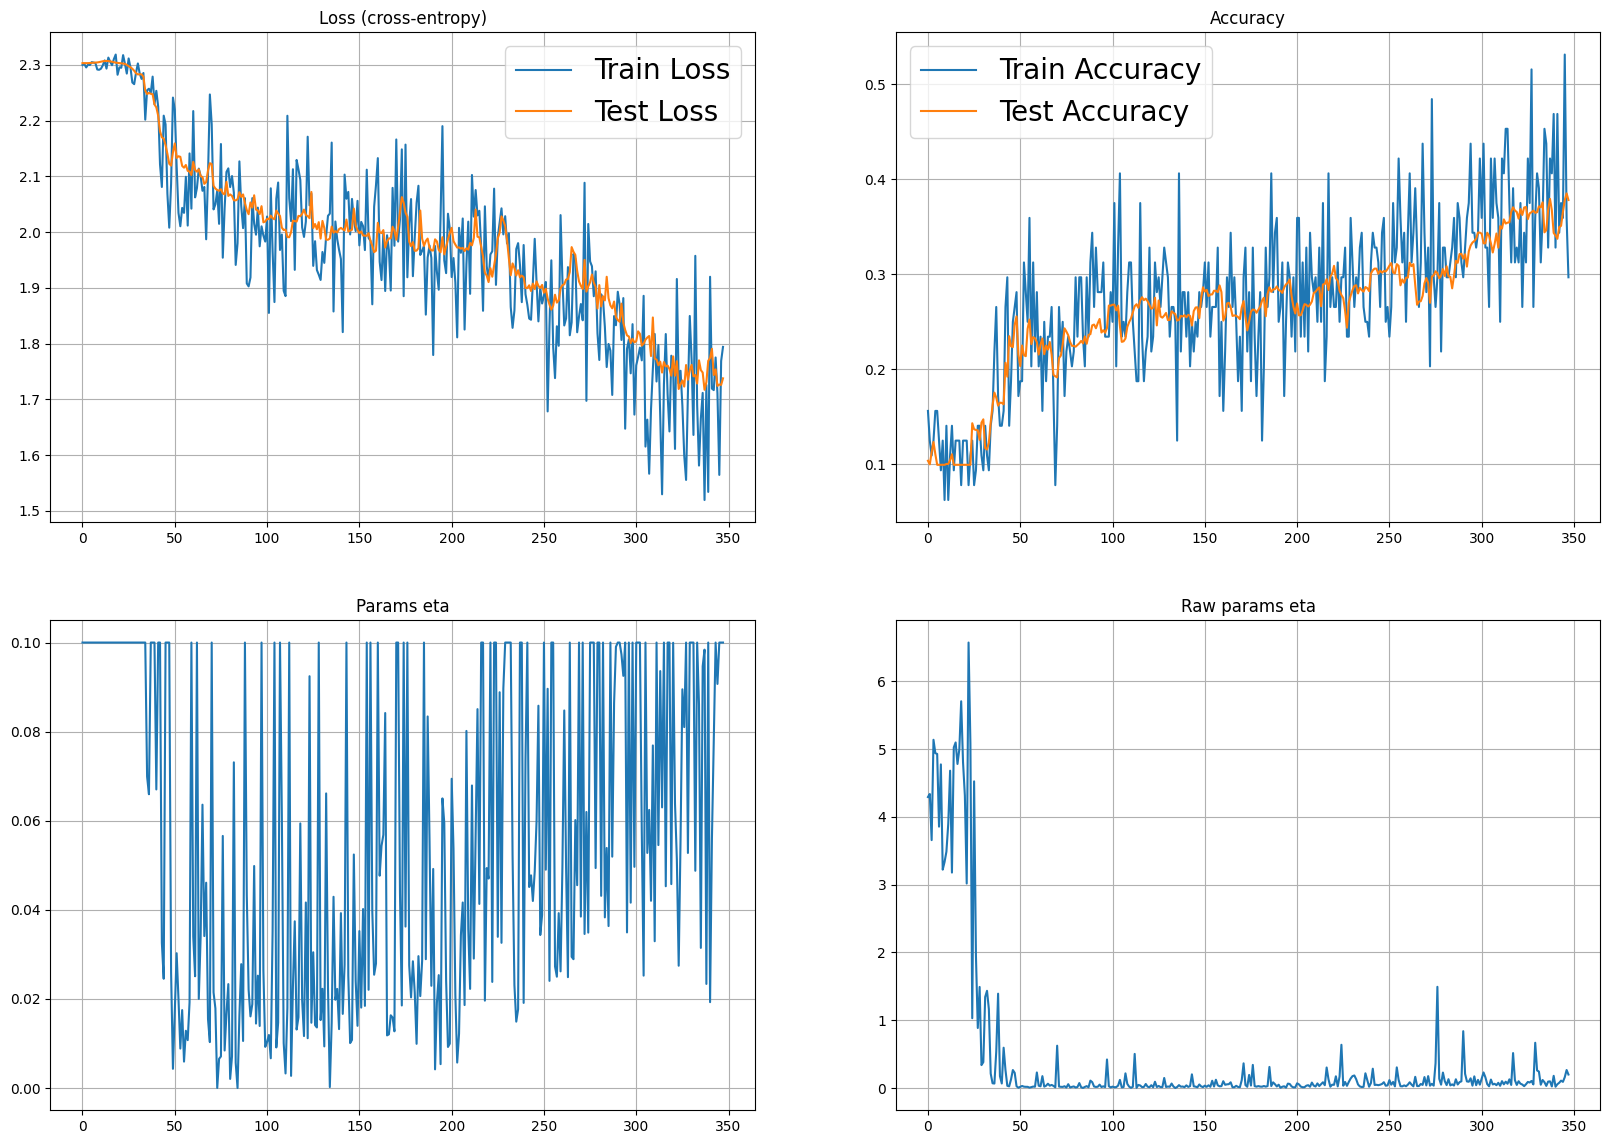

On epoch = 0 test accuracy = 0.3781847133757962


KeyboardInterrupt: 

In [10]:
check_dropout = True
lr = 0.01
stepProcessor = NetLineStepProcessor(testNet, nn.CrossEntropyLoss(), meta, DEVICE)
stepProcessor.c1 = 0.05
stepProcessor.eta_max = 10*lr
stepProcessor.eta_min = 0.01* lr
stepProcessor.eta0 = 0.000_000_5 #0.000_000_25-no-dropout #0.000_000_5
stepProcessor.momentum_gradient_smoothing_coefficient = 10.0 #10.0 if not check_dropout else 0.0
stepProcessor.training_mode=check_dropout
stepProcessor.iter_max = 5

for epoch in range(NUM_EPOCH):
    # training loop
    iter_number = 0
    step_params = {"estimation_type": 'analytic-norm2'} #if not check_dropout \
        #else {"estimation_type": 'analytic-norm2', "check_additional": False} #, 'check_armiho': False
    for train_batch in train_dataloader:
        testNet.train(False)
        iter_number += 1
        images, labels = train_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        logging.info("###--==Step with NetLine norm2 optim: epoch={}, iter={}==--".format(epoch, iter_number))
        step_result = stepProcessor.step(labels, images, momentum=0.9, nesterov=True, step_params = step_params)
        logits_latest = step_result.logits.detach()

        # calculate current average loss and accuracy
        zz_logits = np.transpose(logits_latest.cpu().numpy())
        prediction = logits_latest.argmax(dim=-1)
        loss = loss_crossentropy(zz_logits, labels)
        # save average train loss and accuracy
        HISTORY_PARAMS_N2LAMBDA['train_loss'].append(loss)
        HISTORY_PARAMS_N2LAMBDA['train_accuracy'].append(calculate_accuracy(prediction,labels))
        HISTORY_PARAMS_N2LAMBDA['train_eta'].append(step_result.eta)
        HISTORY_PARAMS_N2LAMBDA['train_eta_raw'].append(step_result.eta_raw) #(min(step_result.eta_raw, stepProcessor.eta_max))

        # testing loop
        #testNet.do_dropout = False
        test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter()
        testNet.eval()
        for test_batch in test_dataloader:
            images, labels = test_batch
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.no_grad():
                xx = images
                logits = testNet.forward_(xx)

                zz_logits = np.transpose(logits.detach().cpu().numpy())
                prediction = logits.argmax(dim=-1).detach()
                loss = loss_crossentropy(zz_logits, labels)
                test_loss_meter.update(loss)
                test_accuracy_meter.update(calculate_accuracy(prediction, labels))

        # save average test accuracy loss and accuracy
        HISTORY_PARAMS_N2LAMBDA['test_loss'].append(test_loss_meter.avg)
        HISTORY_PARAMS_N2LAMBDA['test_accuracy'].append(test_accuracy_meter.avg)
        
        visualise(HISTORY_PARAMS_N2LAMBDA)
        print("On epoch = {} test accuracy = {}".format(epoch, test_accuracy_meter.avg))
